In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, RocCurveDisplay
)

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
pd.set_option("display.max_columns", None)
print("Libraries imported successfully.")

Libraries imported successfully.


In [20]:
df = pd.read_csv("US-pumpkins.csv")
print("First 5 records:")
display(df.head())

First 5 records:


,City Name,Type,Package,Variety,Sub Variety,Grade,Date,Low Price,High Price,Mostly Low,Mostly High,Origin,Origin District,Item Size,Color,Environment,Unit of Sale,Quality,Condition,Appearance,Storage,Crop,Repack,Trans Mode,Unnamed: 24,Unnamed: 25
0,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,4/29/17,270.0,280.0,270.0,280.0,MARYLAND,NaN,lge,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
1,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,5/6/17,270.0,280.0,270.0,280.0,MARYLAND,NaN,lge,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
2,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,160.0,DELAWARE,NaN,med,ORANGE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
3,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,160.0,VIRGINIA,NaN,med,ORANGE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
4,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,11/5/16,90.0,100.0,90.0,100.0,MARYLAND,NaN,lge,ORANGE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN


In [21]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 1757
Number of columns: 26


In [22]:
print("column names:")
display(df.columns.tolist())

column names:


['City Name',
 'Type',
 'Package',
 'Variety',
 'Sub Variety',
 'Grade',
 'Date',
 'Low Price',
 'High Price',
 'Mostly Low',
 'Mostly High',
 'Origin',
 'Origin District',
 'Item Size',
 'Color',
 'Environment',
 'Unit of Sale',
 'Quality',
 'Condition',
 'Appearance',
 'Storage',
 'Crop',
 'Repack',
 'Trans Mode',
 'Unnamed: 24',
 'Unnamed: 25']

In [23]:
print("data types:\n")
print(df.dtypes)

data types:

City Name              str
Type                   str
Package                str
Variety                str
Sub Variety            str
Grade              float64
Date                   str
Low Price          float64
High Price         float64
Mostly Low         float64
Mostly High        float64
Origin                 str
Origin District        str
Item Size              str
Color                  str
Environment        float64
Unit of Sale           str
Quality            float64
Condition          float64
Appearance         float64
Storage            float64
Crop               float64
Repack                 str
Trans Mode         float64
Unnamed: 24        float64
Unnamed: 25            str
dtype: object


In [24]:
print("missing values:")
display(df.isnull().sum())

missing values:


City Name             0
Type               1712
Package               0
Variety               5
Sub Variety        1461
Grade              1757
Date                  0
Low Price             0
High Price            0
Mostly Low          103
Mostly High         103
Origin                3
Origin District    1626
Item Size           279
Color               616
Environment        1757
Unit of Sale       1595
Quality            1757
Condition          1757
Appearance         1757
Storage            1757
Crop               1757
Repack                0
Trans Mode         1757
Unnamed: 24        1757
Unnamed: 25        1654
dtype: int64

In [25]:
df.info

<bound method DataFrame.info of       City Name Type        Package      Variety Sub Variety  Grade     Date  \
0     BALTIMORE  NaN   24 inch bins          NaN         NaN    NaN  4/29/17   
1     BALTIMORE  NaN   24 inch bins          NaN         NaN    NaN   5/6/17   
2     BALTIMORE  NaN   24 inch bins  HOWDEN TYPE         NaN    NaN  9/24/16   
3     BALTIMORE  NaN   24 inch bins  HOWDEN TYPE         NaN    NaN  9/24/16   
4     BALTIMORE  NaN   24 inch bins  HOWDEN TYPE         NaN    NaN  11/5/16   
...         ...  ...            ...          ...         ...    ...      ...   
1752  ST. LOUIS  NaN  22 lb cartons    MINIATURE   FLAT TYPE    NaN  9/30/16   
1753  ST. LOUIS  NaN   36 inch bins    MINIATURE  ROUND TYPE    NaN  9/26/16   
1754  ST. LOUIS  NaN   36 inch bins    MINIATURE  ROUND TYPE    NaN  9/27/16   
1755  ST. LOUIS  NaN   36 inch bins    MINIATURE  ROUND TYPE    NaN  9/28/16   
1756  ST. LOUIS  NaN   36 inch bins    MINIATURE  ROUND TYPE    NaN  9/29/16   

      L

In [26]:
df.describe

<bound method NDFrame.describe of       City Name Type        Package      Variety Sub Variety  Grade     Date  \
0     BALTIMORE  NaN   24 inch bins          NaN         NaN    NaN  4/29/17   
1     BALTIMORE  NaN   24 inch bins          NaN         NaN    NaN   5/6/17   
2     BALTIMORE  NaN   24 inch bins  HOWDEN TYPE         NaN    NaN  9/24/16   
3     BALTIMORE  NaN   24 inch bins  HOWDEN TYPE         NaN    NaN  9/24/16   
4     BALTIMORE  NaN   24 inch bins  HOWDEN TYPE         NaN    NaN  11/5/16   
...         ...  ...            ...          ...         ...    ...      ...   
1752  ST. LOUIS  NaN  22 lb cartons    MINIATURE   FLAT TYPE    NaN  9/30/16   
1753  ST. LOUIS  NaN   36 inch bins    MINIATURE  ROUND TYPE    NaN  9/26/16   
1754  ST. LOUIS  NaN   36 inch bins    MINIATURE  ROUND TYPE    NaN  9/27/16   
1755  ST. LOUIS  NaN   36 inch bins    MINIATURE  ROUND TYPE    NaN  9/28/16   
1756  ST. LOUIS  NaN   36 inch bins    MINIATURE  ROUND TYPE    NaN  9/29/16   

     

In [27]:
print(df["Package"].value_counts(dropna=False))

Package
36 inch bins            663
24 inch bins            551
1/2 bushel cartons      234
1 1/9 bushel cartons    117
35 lb cartons            42
bushel cartons           37
40 lb cartons            19
1 1/9 bushel crates      17
each                     17
bins                     13
50 lb sacks              11
50 lb cartons            10
bushel baskets           10
22 lb cartons            10
20 lb cartons             6
Name: count, dtype: int64


In [28]:
# Keep records where Package contains "bushel"
bushel_df = df[
    df["Package"].astype(str).str.contains("bushel", case=False, na=False)
].copy()

print("Number of bushel records:", len(bushel_df))

display(bushel_df.head())


Number of bushel records: 415


,City Name,Type,Package,Variety,Sub Variety,Grade,Date,Low Price,High Price,Mostly Low,Mostly High,Origin,Origin District,Item Size,Color,Environment,Unit of Sale,Quality,Condition,Appearance,Storage,Crop,Repack,Trans Mode,Unnamed: 24,Unnamed: 25
70,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,9/24/16,15.0,15.0,15.0,15.0,DELAWARE,NaN,med,ORANGE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
71,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,9/24/16,18.0,18.0,18.0,18.0,DELAWARE,NaN,sml,ORANGE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
72,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,10/1/16,18.0,18.0,18.0,18.0,DELAWARE,NaN,sml,ORANGE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
73,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,10/1/16,17.0,17.0,17.0,17.0,OHIO,NaN,med,ORANGE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
74,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,10/8/16,15.0,15.0,15.0,15.0,DELAWARE,NaN,NaN,ORANGE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN


In [29]:
bushel_df = bushel_df[["Package", "Low Price", "High Price", "Date"]].copy()
display(bushel_df.head())

,Package,Low Price,High Price,Date
70,1 1/9 bushel cartons,15.0,15.0,9/24/16
71,1 1/9 bushel cartons,18.0,18.0,9/24/16
72,1 1/9 bushel cartons,18.0,18.0,10/1/16
73,1 1/9 bushel cartons,17.0,17.0,10/1/16
74,1 1/9 bushel cartons,15.0,15.0,10/8/16


In [30]:
bushel_df["Price"] = bushel_df["Low Price"] + bushel_df["High Price"] / 2
bushel_df.head()

,Package,Low Price,High Price,Date,Price
70,1 1/9 bushel cartons,15.0,15.0,9/24/16,22.5
71,1 1/9 bushel cartons,18.0,18.0,9/24/16,27.0
72,1 1/9 bushel cartons,18.0,18.0,10/1/16,27.0
73,1 1/9 bushel cartons,17.0,17.0,10/1/16,25.5
74,1 1/9 bushel cartons,15.0,15.0,10/8/16,22.5


In [31]:
bushel_df["Date"] = pd.to_datetime(bushel_df["Date"])
bushel_df["Month"] = bushel_df["Date"].dt.month
display(bushel_df.head())

,Package,Low Price,High Price,Date,Price,Month
70,1 1/9 bushel cartons,15.0,15.0,2016-09-24,22.5,9
71,1 1/9 bushel cartons,18.0,18.0,2016-09-24,27.0,9
72,1 1/9 bushel cartons,18.0,18.0,2016-10-01,27.0,10
73,1 1/9 bushel cartons,17.0,17.0,2016-10-01,25.5,10
74,1 1/9 bushel cartons,15.0,15.0,2016-10-08,22.5,10


In [32]:
pumpkins_df = bushel_df[["Month", "Package", "Low Price", "High Price", "Price"]].copy()
display(pumpkins_df.head())

,Month,Package,Low Price,High Price,Price
70,9,1 1/9 bushel cartons,15.0,15.0,22.5
71,9,1 1/9 bushel cartons,18.0,18.0,27.0
72,10,1 1/9 bushel cartons,18.0,18.0,27.0
73,10,1 1/9 bushel cartons,17.0,17.0,25.5
74,10,1 1/9 bushel cartons,15.0,15.0,22.5


In [42]:
# Filter records containing "bushel" in Package
bushel_df = df[
    df["Package"].astype(str).str.contains("bushel", case=False, na=False)
].copy()

# Select required columns
pumpkin_df = bushel_df[
    ["Package", "Low Price", "High Price", "Date"]
].copy()

# Convert Date to datetime
pumpkin_df["Date"] = pd.to_datetime(pumpkin_df["Date"])

# Extract month
pumpkin_df["Month"] = pumpkin_df["Date"].dt.month

# Calculate original average price
pumpkin_df["Price"] = (
    pumpkin_df["Low Price"] + pumpkin_df["High Price"]
) / 2

# Display result
display(pumpkin_df.head())


,Package,Low Price,High Price,Date,Month,Price
70,1 1/9 bushel cartons,15.0,15.0,2016-09-24,9,15.0
71,1 1/9 bushel cartons,18.0,18.0,2016-09-24,9,18.0
72,1 1/9 bushel cartons,18.0,18.0,2016-10-01,10,18.0
73,1 1/9 bushel cartons,17.0,17.0,2016-10-01,10,17.0
74,1 1/9 bushel cartons,15.0,15.0,2016-10-08,10,15.0


In [43]:
# Step 12: Adjust price for different package sizes

import re

def get_package_size(package):
    package = str(package).lower().strip()

    # Mixed fraction, e.g. "1 1/9 bushel"
    mixed_fraction = re.search(r'(\d+)\s+(\d+)\s*/\s*(\d+)', package)

    if mixed_fraction:
        whole = float(mixed_fraction.group(1))
        numerator = float(mixed_fraction.group(2))
        denominator = float(mixed_fraction.group(3))

        return whole + (numerator / denominator)

    # Simple fraction, e.g. "1/2 bushel"
    fraction = re.search(r'(\d+)\s*/\s*(\d+)', package)

    if fraction:
        numerator = float(fraction.group(1))
        denominator = float(fraction.group(2))

        return numerator / denominator

    # Whole number, e.g. "1 bushel"
    whole_number = re.search(r'(\d+(?:\.\d+)?)\s*bushel', package)

    if whole_number:
        return float(whole_number.group(1))

    return np.nan


# Extract package size
pumpkin_df["Package Size"] = pumpkin_df["Package"].apply(get_package_size)

# Display package and extracted size
display(
    pumpkin_df[["Package", "Package Size"]].drop_duplicates()
)

,Package,Package Size
70,1 1/9 bushel cartons,1.111111
123,1/2 bushel cartons,0.500000
377,1 1/9 bushel crates,1.111111
489,bushel cartons,NaN
1569,bushel baskets,NaN


In [45]:
# Calculate price per bushel

pumpkin_df["Low Price"] = (
    pumpkin_df["Low Price"] / pumpkin_df["Package Size"]
)

pumpkin_df["High Price"] = (
    pumpkin_df["High Price"] / pumpkin_df["Package Size"]
)

pumpkin_df["Price"] = (
    pumpkin_df["Low Price"] + pumpkin_df["High Price"]
) / 2

display(pumpkin_df.head())


,Package,Low Price,High Price,Date,Month,Price,Package Size
70,1 1/9 bushel cartons,13.5,13.5,2016-09-24,9,13.5,1.111111
71,1 1/9 bushel cartons,16.2,16.2,2016-09-24,9,16.2,1.111111
72,1 1/9 bushel cartons,16.2,16.2,2016-10-01,10,16.2,1.111111
73,1 1/9 bushel cartons,15.3,15.3,2016-10-01,10,15.3,1.111111
74,1 1/9 bushel cartons,13.5,13.5,2016-10-08,10,13.5,1.111111


In [46]:
pumpkins_df = pumpkin_df.dropna(
    subset=["Month", "Package", "Low Price", "High Price", "Price"]
). copy()

print("Final number of records:", len(pumpkins_df))

Final number of records: 368


In [47]:
monthly_price = (
    pumpkin_df
    .groupby("Month")["Price"]
    .mean()
    .reset_index()
)

monthly_price.columns = ["Month", "Average Price"]

display(monthly_price)


,Month,Average Price
0,8,24.366667
1,9,28.415650
2,10,28.329520
3,11,25.107018
4,12,15.412500


In [50]:
month_names = {
    1: "January",
    2: "February",
    3: "March",
    4: "April",
    5: "May",
    6: "June",
    7: "July",
    8: "August",
    9: "September",
    10: "October",
    11: "November",
    12: "December"
}

monthly_price["Month Name"] = monthly_price["Month"].map(month_names)

print(monthly_price)


   Month  Average Price Month Name
0      8      24.366667     August
1      9      28.415650  September
2     10      28.329520    October
3     11      25.107018   November
4     12      15.412500   December


In [51]:
highest_month = monthly_price.loc[
    monthly_price["Average Price"].idxmax()
]

lowest_month = monthly_price.loc[
    monthly_price["Average Price"].idxmin()
]

print(
    "Highest average price:",
    highest_month["Month Name"],
    "=", 
    round(highest_month["Average Price"], 2)
)

print(
    "Lowest average price:",
    lowest_month["Month Name"],
    "=",
    round(lowest_month["Average Price"], 2)
)


Highest average price: September = 28.42
Lowest average price: December = 15.41


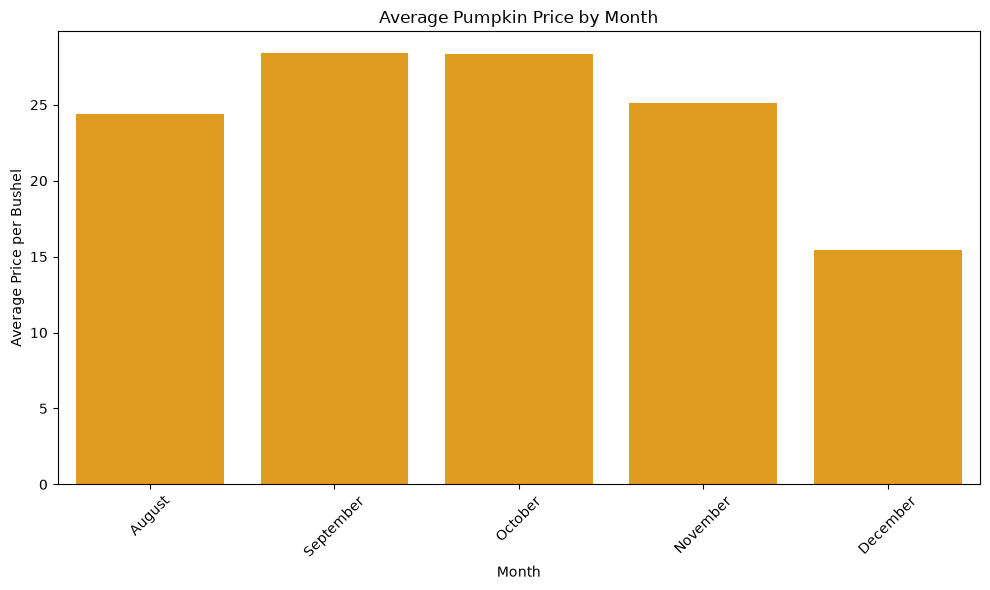

In [53]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=monthly_price,
    x="Month Name",
    y="Average Price",
    color="orange"
)

plt.title("Average Pumpkin Price by Month")
plt.xlabel("Month")
plt.ylabel("Average Price per Bushel")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


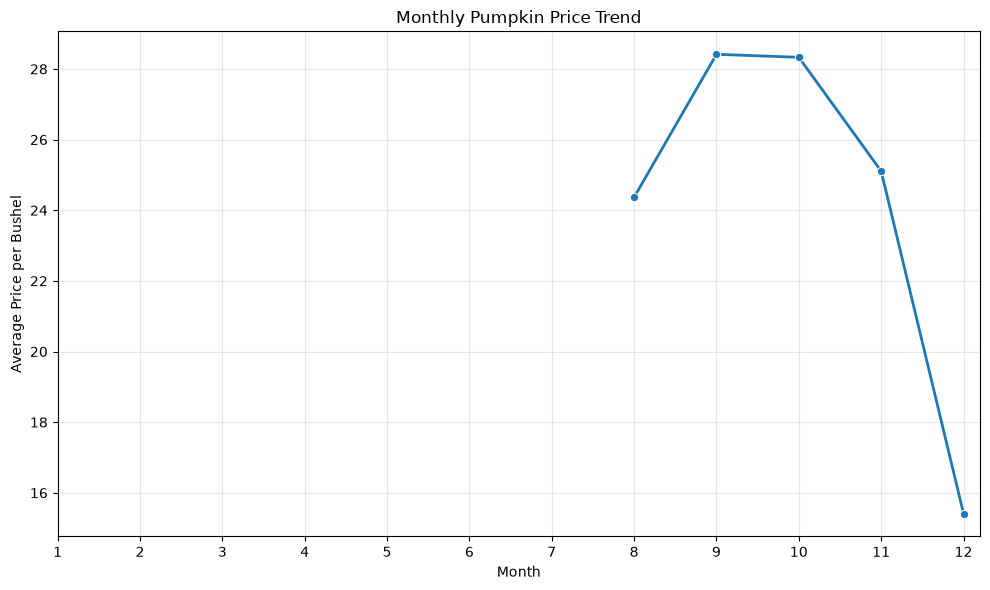

In [62]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=monthly_price,
    x="Month",
    y="Average Price",
    marker="o",
    linewidth=2
)

plt.title("Monthly Pumpkin Price Trend")
plt.xlabel("Month")
plt.ylabel("Average Price per Bushel")
plt.xticks(range(1, 13))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


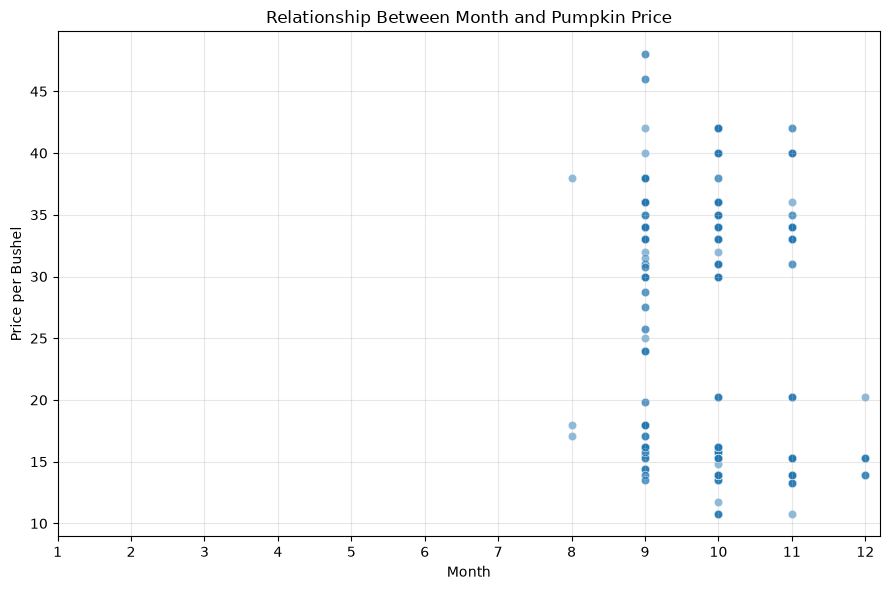

In [71]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=pumpkin_df,
    x="Month",
    y="Price",
    alpha=0.5
)

plt.title("Relationship Between Month and Pumpkin Price")
plt.xlabel("Month")
plt.ylabel("Price per Bushel")
plt.xticks(range(1, 13))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [74]:
correlation_df = pumpkin_df[
    ["Month", "Low Price", "High Price", "Price"]
]
correlation_matrix = correlation_df.corr()
display(correlation_matrix)


,Month,Low Price,High Price,Price
Month,1.000000,-0.149672,-0.154460,-0.153018
Low Price,-0.149672,1.000000,0.977520,0.993929
High Price,-0.154460,0.977520,1.000000,0.994783
Price,-0.153018,0.993929,0.994783,1.000000


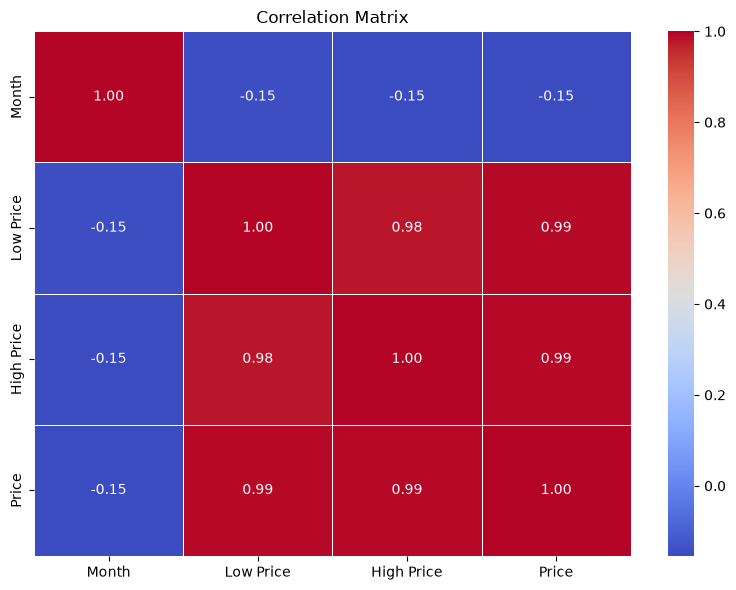

In [82]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


In [84]:
price_correlations = correlation_matrix["Price"].drop("Price")

strongest_variable = price_correlations.abs().idxmax()
strongest_correlation = price_correlations[strongest_variable]

print("Strongest relationship with Price:", strongest_variable)
print("Correlation:", round(strongest_correlation, 3))


Strongest relationship with Price: High Price
Correlation: 0.995


In [85]:
r = abs(strongest_correlation)

if r < 0.3:
    strength = "weak"
elif r < 0.7:
    strength = "moderate"
else:
    strength = "strong"

direction = "positive" if strongest_correlation > 0 else "negative"

print("Direction:", direction)
print("Strength:", strength)


Direction: positive
Strength: strong


In [90]:
# x = Month
# y = Price
X = pumpkin_df[["Month"]]
y = pumpkin_df[["Price"]]

print("X:")
display(X.head())

print("y:")
display(y.head())
                

X:


,Month
70,9
71,9
72,10
73,10
74,10


y:


,Price
70,13.5
71,16.2
72,16.2
73,15.3
74,13.5


In [116]:
# Part E - Simple Linear Regression

from sklearn.linear_model import LinearRegression

# Remove rows with missing Month or Price
model_df = pumpkin_df.dropna(
    subset=["Month", "Price"]
).copy()

# Prepare X and y
X = model_df[["Month"]]
y = model_df["Price"]

# Create the model
model = LinearRegression()

# Train the model
model.fit(X, y)

print("Model trained successfully!")
print("Number of records used:", len(model_df))


Model trained successfully!
Number of records used: 368


In [117]:
print("Missing values in X:")
print(X.isnull().sum())

print("\nMissing values in y:")
print(y.isnull().sum())


Missing values in X:
Month    0
dtype: int64

Missing values in y:
0


In [119]:
print(
    f"Price = {model.intercept_:.4f} "
    f"+ ({model.coef_[0]:.4f} × Month)"
)


Price = 46.7888 + (-1.9540 × Month)


In [122]:
# Part E - #25 Generate Predictions

# Generate predictions using the same X used to train the model
y_pred = model.predict(X)

# Add predictions to model_df
model_df["Predicted Price"] = y_pred

# Display actual vs predicted prices
comparison = model_df[
    ["Month", "Price", "Predicted Price"]
].copy()

display(comparison.head(10))


,Month,Price,Predicted Price
70,9,13.500,29.202716
71,9,16.200,29.202716
72,10,16.200,27.248711
73,10,15.300,27.248711
74,10,13.500,27.248711
75,10,16.200,27.248711
76,10,15.300,27.248711
77,10,15.975,27.248711
78,10,13.500,27.248711
79,10,15.300,27.248711


In [123]:
print("Number of rows:", len(model_df))
print("Number of predictions:", len(y_pred))


Number of rows: 368
Number of predictions: 368


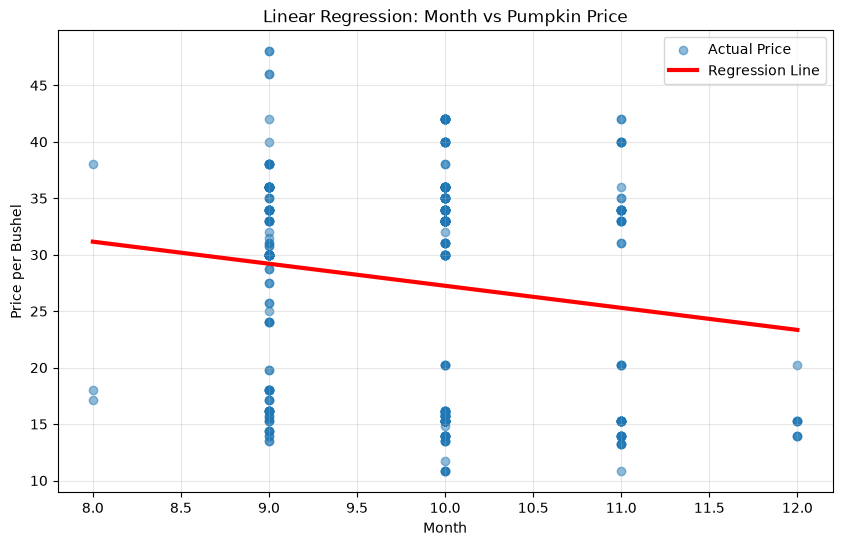

In [125]:
plt.figure(figsize=(10, 6))

# Actual prices
plt.scatter(
    model_df["Month"],
    model_df["Price"],
    alpha=0.5,
    label="Actual Price"
)

# Regression line
month_values = np.linspace(
    model_df["Month"].min(),
    model_df["Month"].max(),
    100
).reshape(-1, 1)

price_predictions = model.predict(month_values)

plt.plot(
    month_values,
    price_predictions,
    color="red",
    linewidth=3,
    label="Regression Line"
)

plt.title("Linear Regression: Month vs Pumpkin Price")
plt.xlabel("Month")
plt.ylabel("Price per Bushel")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [126]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(
    model_df["Price"],
    model_df["Predicted Price"]
)

mse = mean_squared_error(
    model_df["Price"],
    model_df["Predicted Price"]
)

r2 = r2_score(
    model_df["Price"],
    model_df["Predicted Price"]
)

print("MAE:", mae)
print("MSE:", mse)
print("R²:", r2)


MAE: 8.70045187048198
MSE: 93.24703498223224
R²: 0.023414365534992432
